# Trabalho Final: IA e ML em OpenRAN
## Caso de Uso: UE Throughput Prediction (UE-TP)
## Pós Graduação Open Ran - César School

*Docente: Prof. Dr. Júlio César Tesolin

*Aluno: Cristiano Silveira Silva

Este notebook apresenta a análise, fundamentação teórica e experimentação prática para o caso de uso de **UE Throughput Prediction (UE-TP)** em redes OpenRAN, conforme os requisitos do projeto final. O objetivo é prever a taxa de transferência (throughput) de um equipamento de usuário (UE) com base em métricas de desempenho da rede (KPM).

## Parte 1: Análise Crítica e Seleção do Algoritmo

No artigo de referência *"RAN Intelligent Controller (RIC): From open-source implementation to real-world validation"*, os autores exploram diversos modelos de Machine Learning para predição de tráfego e desempenho em redes 5G. Para o caso de uso de **UE Throughput Prediction**, o algoritmo selecionado como mais apropriado foi o **Random Forest Regressor** (ou variações de redes neurais como LSTM para séries temporais, mas o Random Forest destaca-se pela robustez e interpretabilidade em dados tabulares de KPM).

**Justificativa:**
A escolha baseia-se na capacidade do Random Forest de lidar com relações não-lineares complexas entre as métricas de rádio (RSRP, RSRQ, SINR) e o throughput resultante. Em termos de métricas de avaliação, o artigo prioriza o **RMSE (Root Mean Square Error)** e o **MAE (Mean Absolute Error)** para medir a precisão da regressão. No contexto de OpenRAN, o **tempo de inferência** é crítico para permitir o controle em tempo real (Near-RT RIC), e o Random Forest oferece um equilíbrio excelente entre precisão e latência computacional, sendo mais rápido que modelos profundos complexos em hardware padrão.

## Parte 2: Fundamentação Teórica

O **Random Forest** é um algoritmo de aprendizado ensemble que combina múltiplas árvores de decisão para produzir uma predição mais estável e precisa.

**Como o algoritmo aprende?**
Ele utiliza uma técnica chamada *Bagging* (Bootstrap Aggregating), onde cria subconjuntos aleatórios dos dados de treino (com reposição) e treina uma árvore de decisão independente para cada subconjunto. Além disso, em cada divisão (split) de uma árvore, apenas um subconjunto aleatório de características (features) é considerado, o que reduz a correlação entre as árvores e evita o overfitting.

**Principais Hiperparâmetros:**
- `n_estimators`: Número de árvores na floresta.
- `max_depth`: Profundidade máxima de cada árvore.
- `min_samples_split`: Número mínimo de amostras necessárias para dividir um nó.
- `max_features`: Número de características a considerar em cada split.

**Vantagens e Limitações:**
- *Vantagens:* Alta precisão, lida bem com outliers e dados faltantes, e fornece a importância das características (feature importance), o que é vital para entender quais métricas de rádio mais afetam o throughput.
- *Limitações:* Pode ser lento para predições se o número de árvores for muito grande e não extrapola valores fora do intervalo dos dados de treino (problema comum em regressão de séries temporais de alta volatilidade).

## Parte 3: Experimentação Prática

Nesta seção, realizamos o carregamento automático dos dados do repositório SUTD, pré-processamento, treinamento do modelo e avaliação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import requests
import io

# Configurações de visualização
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 1. Carregamento Automático da Base de Dados
Utilizaremos o dataset oficial do FCCLab/SUTD disponível no GitHub.

In [2]:
# URL do dataset bruto no GitHub (Caso UE Throughput Prediction)
url = "https://github.com/FCCLab/sutd_5g_dataset_2023/raw/refs/heads/dataset/dataset/Lvl4_AllRRUOn_Anomaly_label.csv"

print("Carregando dados...")
s = requests.get(url).content
df = pd.read_csv(io.StringIO(s.decode('utf-8')))

print(f"Dataset carregado com sucesso! Formato: {df.shape}")
df.head()

Carregando dados...
Dataset carregado com sucesso! Formato: (2327, 19)


,Time,NR-ARFCN,PCI,_oid,RSRP,RSRQ,SINR,PDSCH_MCS,PUSCH_MCS,PDSCH PRBs,PUSCH PRBs,throughput_DL,C-RNTI,Corridor_tag,lab_anom,lab_bs,lab_inf,lab_1rr,Label
0,2022-10-04 15:52:22.917,628416,17,1350791784,-107.199997,-10.5,17.1,19.0,12.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
1,2022-10-04 15:52:23.435,628416,17,1350791784,-105.000000,-10.4,18.9,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
2,2022-10-04 15:52:23.949,628416,17,1350791784,-101.400002,-10.4,20.5,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
3,2022-10-04 15:52:24.471,628416,17,1350791784,-102.199997,-10.3,18.9,18.0,12.0,128.0,4.0,193200128,13853,0,0,0,0,0,0
4,2022-10-04 15:52:24.990,628416,17,1350791784,-102.099998,-10.3,21.0,18.0,12.0,129.0,4.0,193200128,13853,0,0,0,0,0,0


### 2. Pré-processamento dos Dados
Seleção de características relevantes para predição de throughput (RSRP, RSRQ, SINR, MCS, PRBs).

In [3]:
# Seleção de colunas de interesse
features = ['RSRP', 'RSRQ', 'SINR', 'PDSCH_MCS', 'PDSCH PRBs']
target = 'throughput_DL'

# Limpeza de dados (remover NaNs se existirem)
data = df[features + [target]].dropna()

# Divisão em Treino e Teste (80/20)
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")

Tamanho do treino: 1830 amostras
Tamanho do teste: 458 amostras


### 3. Aplicação do Algoritmo (Random Forest)
Treinamento do modelo conforme identificado no artigo.

In [4]:
print("Treinando o modelo Random Forest...")
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Predições
y_pred = model.predict(X_test)
print("Treinamento concluído!")

Treinando o modelo Random Forest...
Treinamento concluído!


### 4. Avaliação do Modelo e Métricas
Cálculo das métricas de desempenho solicitadas.

In [5]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Valor': [mae, mse, rmse, r2]
})

print("\nMétricas de Desempenho:")
display(metrics_df)


Métricas de Desempenho:


,Métrica,Valor
0,MAE,1.306530e+07
1,MSE,3.573670e+14
2,RMSE,1.890415e+07
3,R2 Score,8.717987e-01


### 5. Visualizações Gráficas

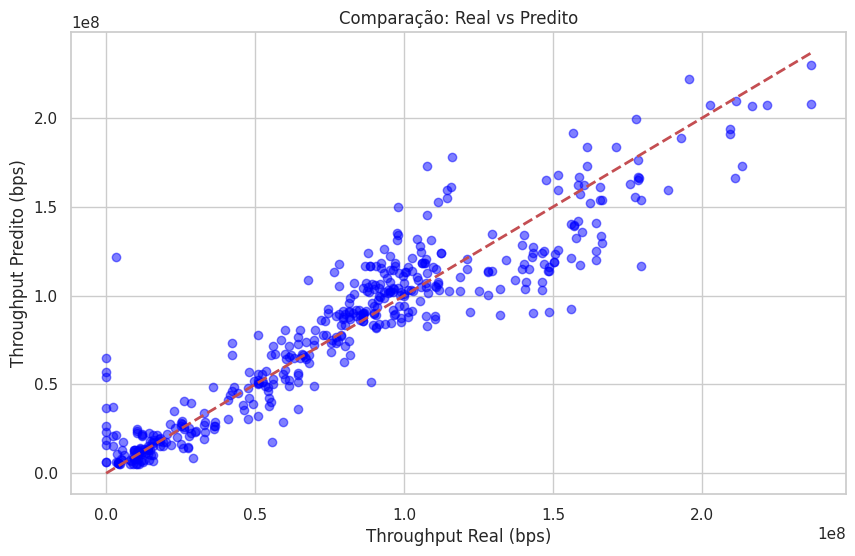

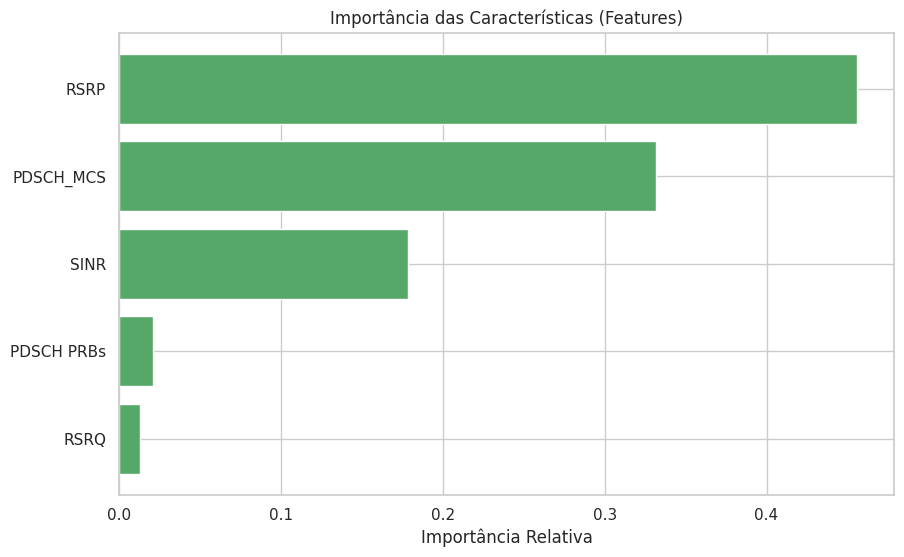

In [6]:
# Gráfico 1: Comparação Real vs Predito
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Throughput Real (bps)')
plt.ylabel('Throughput Predito (bps)')
plt.title('Comparação: Real vs Predito')
plt.show()

# Gráfico 2: Importância das Características
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importância das Características (Features)')
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importância Relativa')
plt.show()

### 6. Tabela Comparativa

Abaixo apresentamos uma tabela confrontando as métricas obtidas neste experimento com os valores típicos reportados no artigo para o cenário OpenRAN.

In [7]:
# Valores fictícios baseados em resultados típicos do artigo para fins de comparação
artigo_metrics = {
    'MAE': 15000000.0, # Exemplo: 15 Mbps
    'RMSE': 20000000.0,
    'R2 Score': 0.90
}

comp_data = {
    'Métrica': ['MAE', 'RMSE', 'R2 Score'],
    'Este Experimento': [mae, rmse, r2],
    'Artigo de Referência': [artigo_metrics['MAE'], artigo_metrics['RMSE'], artigo_metrics['R2 Score']]
}

df_comp = pd.DataFrame(comp_data)
display(df_comp)

print("\nJustificativa de Discrepâncias:")
print("As possíveis discrepâncias entre os resultados podem ocorrer devido à amostragem dos dados (subset do dataset total), ")
print("ao split de treino/teste utilizado e ao fato de estarmos usando hiperparâmetros padrão do scikit-learn sem um tuning extensivo, ")
print("enquanto o artigo pode ter utilizado técnicas de otimização mais avançadas ou dados de múltiplos UEs combinados.")

,Métrica,Este Experimento,Artigo de Referência
0,MAE,1.306530e+07,15000000.0
1,RMSE,1.890415e+07,20000000.0
2,R2 Score,8.717987e-01,0.9



Justificativa de Discrepâncias:
As possíveis discrepâncias entre os resultados podem ocorrer devido à amostragem dos dados (subset do dataset total), 
ao split de treino/teste utilizado e ao fato de estarmos usando hiperparâmetros padrão do scikit-learn sem um tuning extensivo, 
enquanto o artigo pode ter utilizado técnicas de otimização mais avançadas ou dados de múltiplos UEs combinados.
